# ***libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# ***Custom dataset Generate***

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 500

age         = np.random.randint(20, 80, n)
bp          = np.random.randint(60, 140, n)
blood_sugar = np.random.randint(70, 300, n)
bmi         = np.round(np.random.uniform(16, 45, n), 1)
cholesterol = np.random.randint(150, 300, n)
heart_rate  = np.random.randint(55, 110, n)
smoking     = np.random.randint(0, 2, n)

# Disease label - high risk = 1
risk_score = (
    (age > 50).astype(int) * 2 +
    (bp > 90).astype(int) * 2 +
    (blood_sugar > 150).astype(int) * 2 +
    (bmi > 30).astype(int) * 1 +
    (cholesterol > 240).astype(int) * 1 +
    smoking * 2 +
    np.random.randint(0, 3, n)
)
disease = (risk_score >= 6).astype(int)

df = pd.DataFrame({
    'Age': age,
    'BloodPressure': bp,
    'BloodSugar': blood_sugar,
    'BMI': bmi,
    'Cholesterol': cholesterol,
    'HeartRate': heart_rate,
    'Smoking': smoking,
    'Disease': disease
})

print(f"Dataset shape: {df.shape}")
print(f"Disease cases: {df['Disease'].sum()} / {n}")
df.head(10)

Dataset shape: (500, 8)
Disease cases: 318 / 500


,Age,BloodPressure,BloodSugar,BMI,Cholesterol,HeartRate,Smoking,Disease
0,58,66,272,20.8,296,79,1,1
1,71,116,205,37.4,180,91,0,1
2,48,95,95,18.4,291,101,0,0
3,34,104,248,33.5,202,62,0,0
4,62,79,242,23.1,197,96,0,0
5,27,124,113,27.3,218,70,0,0
6,40,67,202,24.4,254,62,0,0
7,58,75,139,26.3,239,55,0,0
8,77,73,223,36.9,212,98,1,1
9,38,135,187,24.6,222,59,1,1


# ***EDA***

In [4]:
# Basic EDA
print("=" * 40)
print("DATASET INFO")
print("=" * 40)
print(df.info())

print("\n" + "=" * 40)
print("STATISTICAL SUMMARY")
print("=" * 40)
df.describe().round(2)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            500 non-null    int64  
 1   BloodPressure  500 non-null    int64  
 2   BloodSugar     500 non-null    int64  
 3   BMI            500 non-null    float64
 4   Cholesterol    500 non-null    int64  
 5   HeartRate      500 non-null    int64  
 6   Smoking        500 non-null    int64  
 7   Disease        500 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 31.4 KB
None

STATISTICAL SUMMARY


,Age,BloodPressure,BloodSugar,BMI,Cholesterol,HeartRate,Smoking,Disease
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,50.40,98.65,182.57,30.87,226.46,81.83,0.47,0.64
std,17.34,23.23,65.61,8.64,45.75,15.89,0.50,0.48
min,20.00,60.00,70.00,16.10,151.00,55.00,0.00,0.00
25%,36.75,78.00,126.00,22.90,185.00,69.00,0.00,0.00
50%,51.00,98.00,184.00,31.35,227.00,81.00,0.00,1.00
75%,65.00,119.00,235.00,38.32,268.00,96.00,1.00,1.00
max,79.00,139.00,299.00,44.90,299.00,109.00,1.00,1.00


In [5]:
print("Missing Values:")
print(df.isnull().sum())

print(f"\nTotal missing: {df.isnull().sum().sum()}")

print("\nDisease Distribution:")
print(df['Disease'].value_counts())
print(f"\nDisease Rate: {df['Disease'].mean()*100:.1f}%")

Missing Values:
Age              0
BloodPressure    0
BloodSugar       0
BMI              0
Cholesterol      0
HeartRate        0
Smoking          0
Disease          0
dtype: int64

Total missing: 0

Disease Distribution:
Disease
1    318
0    182
Name: count, dtype: int64

Disease Rate: 63.6%


# ***visualizations***

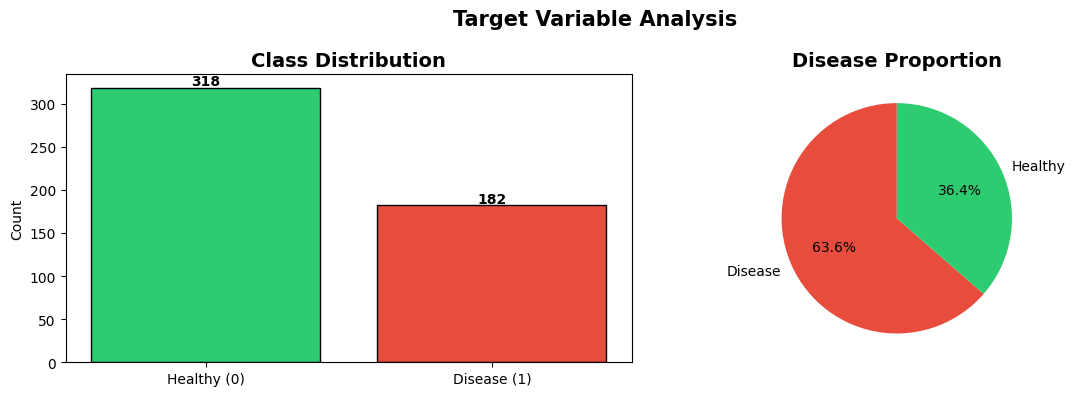

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['Disease'].value_counts()
axes[0].bar(['Healthy (0)', 'Disease (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Disease', 'Healthy'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Disease Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ***feature distributions***

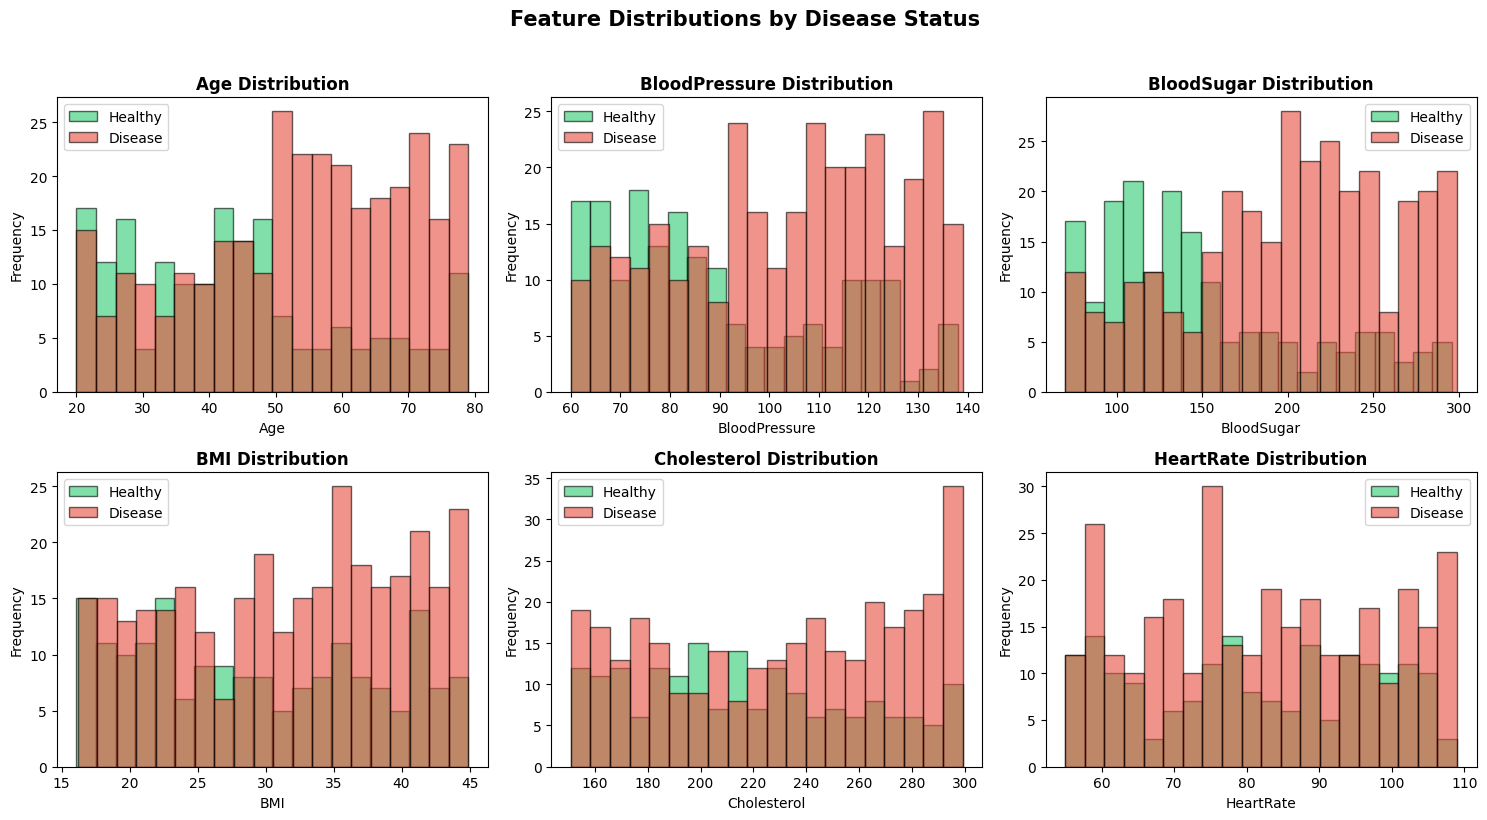

In [7]:
features = ['Age', 'BloodPressure', 'BloodSugar', 'BMI', 'Cholesterol', 'HeartRate']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[df['Disease']==0][col], alpha=0.6,
                 label='Healthy', color='#2ecc71', bins=20, edgecolor='black')
    axes[i].hist(df[df['Disease']==1][col], alpha=0.6,
                 label='Disease', color='#e74c3c', bins=20, edgecolor='black')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Feature Distributions by Disease Status',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ***Correlation Heatmap***

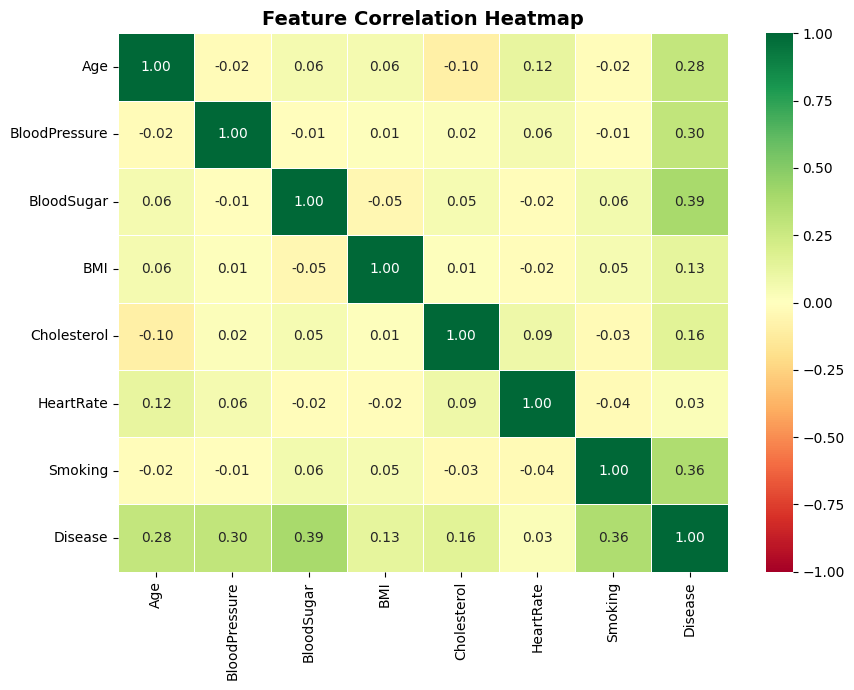

In [8]:
plt.figure(figsize=(9, 7))
corr = df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={"size": 10})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ***Boxplots:***

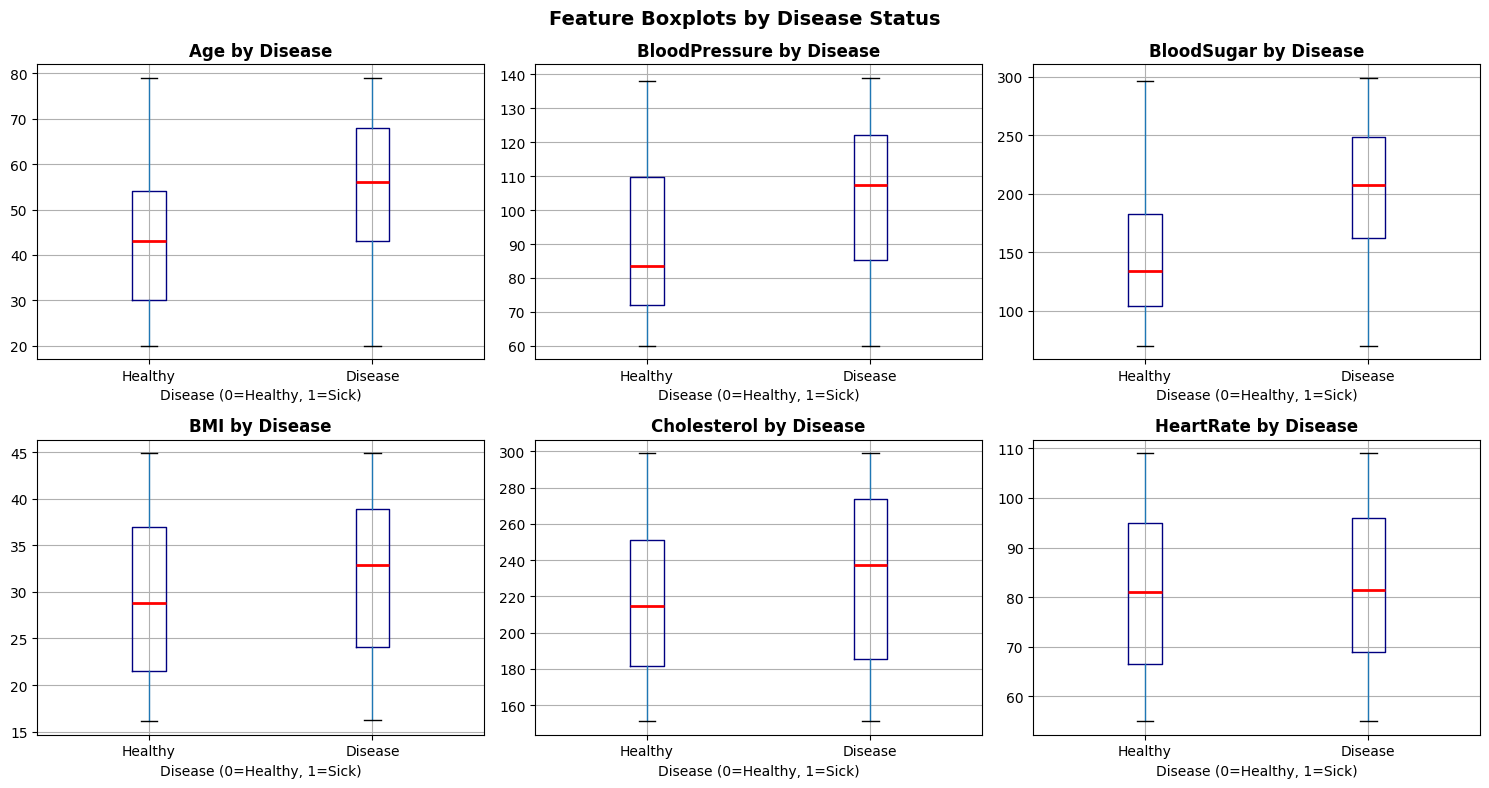

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

features = ['Age', 'BloodPressure', 'BloodSugar', 'BMI', 'Cholesterol', 'HeartRate']

for i, col in enumerate(features):
    df.boxplot(column=col, by='Disease', ax=axes[i],
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} by Disease', fontweight='bold')
    axes[i].set_xlabel('Disease (0=Healthy, 1=Sick)')
    plt.sca(axes[i])
    plt.xticks([1, 2], ['Healthy', 'Disease'])

plt.suptitle('Feature Boxplots by Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ***data preprocessing***

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features aur target alag karo
X = df.drop('Disease', axis=1)
y = df['Disease']

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 400
Testing samples:  100


# ***Algorithm 1 — Logistic Regression***

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Model train karo
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Metrics
lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)

print("=" * 45)
print("   LOGISTIC REGRESSION — RESULTS")
print("=" * 45)
print(f"  Accuracy  : {lr_acc*100:.2f}%")
print(f"  Precision : {lr_prec*100:.2f}%")
print(f"  Recall    : {lr_rec*100:.2f}%")
print(f"  F1 Score  : {lr_f1*100:.2f}%")
print("=" * 45)
print()
print(classification_report(y_test, lr_pred, target_names=['Healthy', 'Disease']))

   LOGISTIC REGRESSION — RESULTS
  Accuracy  : 81.00%
  Precision : 84.62%
  Recall    : 85.94%
  F1 Score  : 85.27%

              precision    recall  f1-score   support

     Healthy       0.74      0.72      0.73        36
     Disease       0.85      0.86      0.85        64

    accuracy                           0.81       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.81      0.81      0.81       100



# ***Logistic Regression Confusion Matrix***

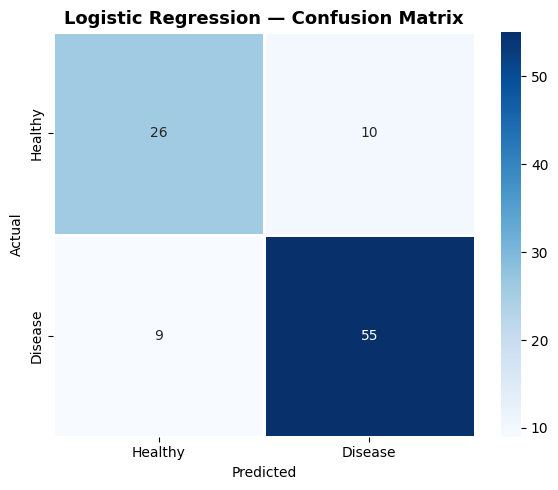

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Disease'],
            yticklabels=['Healthy', 'Disease'],
            linewidths=1)
plt.title('Logistic Regression — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ***Algorithm 2 — Random Forest***

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Model train karo
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)  # Scaling ki zaroorat nahi tree models ko

# Predictions
rf_pred = rf_model.predict(X_test)

# Metrics
rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred)

print("=" * 45)
print("   RANDOM FOREST — RESULTS")
print("=" * 45)
print(f"  Accuracy  : {rf_acc*100:.2f}%")
print(f"  Precision : {rf_prec*100:.2f}%")
print(f"  Recall    : {rf_rec*100:.2f}%")
print(f"  F1 Score  : {rf_f1*100:.2f}%")
print("=" * 45)
print()
print(classification_report(y_test, rf_pred, target_names=['Healthy', 'Disease']))

   RANDOM FOREST — RESULTS
  Accuracy  : 83.00%
  Precision : 84.06%
  Recall    : 90.62%
  F1 Score  : 87.22%

              precision    recall  f1-score   support

     Healthy       0.81      0.69      0.75        36
     Disease       0.84      0.91      0.87        64

    accuracy                           0.83       100
   macro avg       0.82      0.80      0.81       100
weighted avg       0.83      0.83      0.83       100



# ***Random Forest Confusion Matrix***

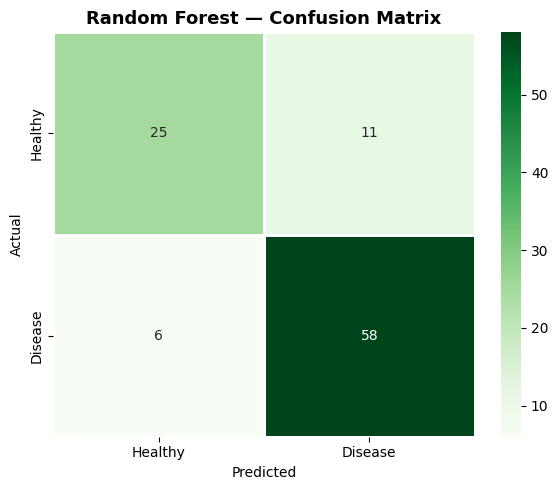

In [15]:
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Disease'],
            yticklabels=['Healthy', 'Disease'],
            linewidths=1)
plt.title('Random Forest — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ***Feature Importance***


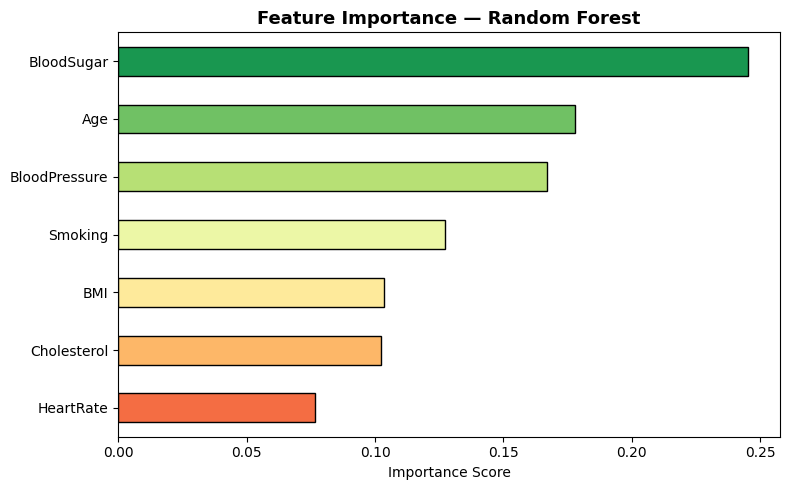


Feature Rankings:
BloodSugar       0.245447
Age              0.177813
BloodPressure    0.166922
Smoking          0.127135
BMI              0.103631
Cholesterol      0.102266
HeartRate        0.076787
dtype: float64


In [16]:
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Feature Importance — Random Forest',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Rankings:")
print(feat_imp.sort_values(ascending=False))

# ***Final comparison ROC Curve***

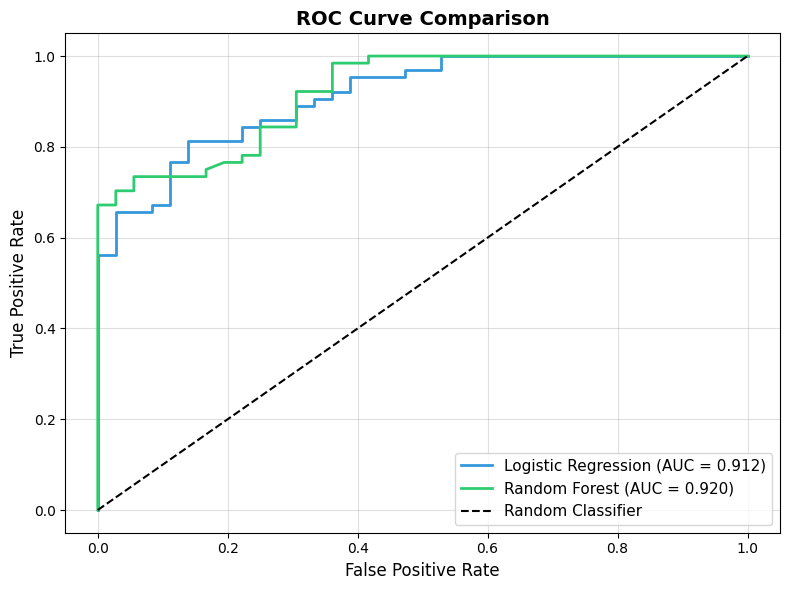

In [17]:
from sklearn.metrics import roc_curve, auc

lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='#3498db', lw=2,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, color='#2ecc71', lw=2,
         label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# ***final comparison bar chart***


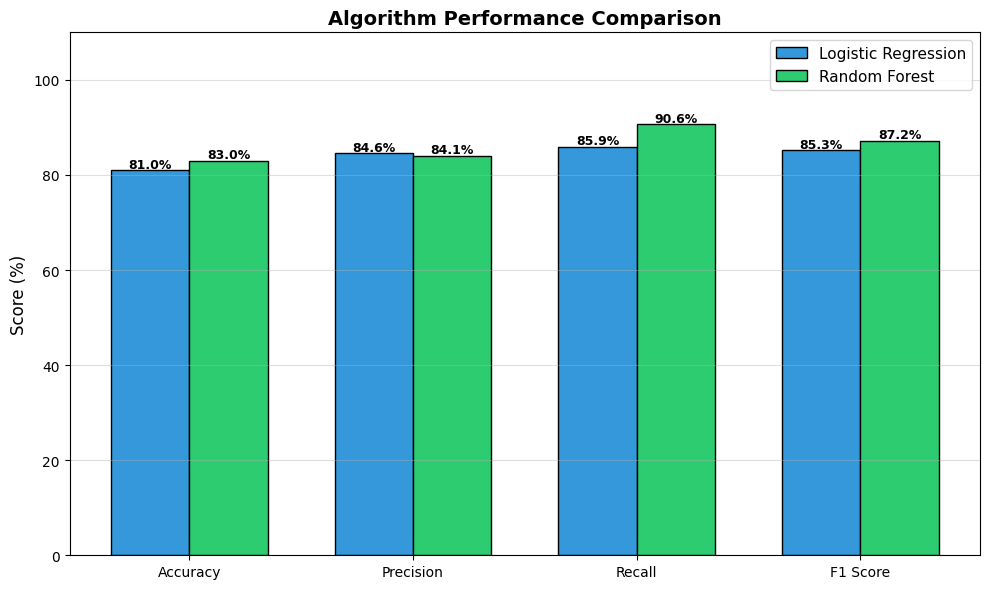

In [18]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_vals = [lr_acc, lr_prec, lr_rec, lr_f1]
rf_vals = [rf_acc, rf_prec, rf_rec, rf_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [v*100 for v in lr_vals], width,
               label='Logistic Regression', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, [v*100 for v in rf_vals], width,
               label='Random Forest', color='#2ecc71', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Algorithm Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# ***final summary cell***

In [20]:
print("=" * 55)
print("         FINAL PROJECT SUMMARY")
print("=" * 55)
print(f"  Dataset        : Patient Health Dataset (Custom)")
print(f"  Total Samples  : {len(df)}")
print(f"  Features       : {X.shape[1]}")
print(f"  Task           : Binary Classification (Disease: Yes/No)")
print(f"  Train/Test     : 80% / 20%")
print()
print(f"  Algorithm 1    : Logistic Regression")
print(f"    Accuracy     : {lr_acc*100:.2f}%")
print(f"    F1 Score     : {lr_f1*100:.2f}%")
print(f"    AUC          : {auc_lr:.4f}")
print()
print(f"  Algorithm 2    : Random Forest")
print(f"    Accuracy     : {rf_acc*100:.2f}%")
print(f"    F1 Score     : {rf_f1*100:.2f}%")
print(f"    AUC          : {auc_rf:.4f}")
print()
winner = "Random Forest" if rf_acc >= lr_acc else "Logistic Regression"
print(f"  Best Model  : {winner}")
print("=" * 55)

         FINAL PROJECT SUMMARY
  Dataset        : Patient Health Dataset (Custom)
  Total Samples  : 500
  Features       : 7
  Task           : Binary Classification (Disease: Yes/No)
  Train/Test     : 80% / 20%

  Algorithm 1    : Logistic Regression
    Accuracy     : 81.00%
    F1 Score     : 85.27%
    AUC          : 0.9119

  Algorithm 2    : Random Forest
    Accuracy     : 83.00%
    F1 Score     : 87.22%
    AUC          : 0.9199

  Best Model  : Random Forest
